# Import Libraries and modules

In [268]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings('ignore') 

### Read and Explore Dataset

In [269]:
pd.set_option('display.max_columns', None)

In [270]:
df = pd.read_excel('data/E_Commerce_Dataset.xlsx', sheet_name='E Comm')

In [271]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [272]:
df.shape

(5630, 20)

In [273]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [274]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [275]:
df.isnull().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [276]:
df.duplicated().sum()

np.int64(0)

In [277]:
df.nunique()

CustomerID                     5630
Churn                             2
Tenure                           36
PreferredLoginDevice              3
CityTier                          3
WarehouseToHome                  34
PreferredPaymentMode              7
Gender                            2
HourSpendOnApp                    6
NumberOfDeviceRegistered          6
PreferedOrderCat                  6
SatisfactionScore                 5
MaritalStatus                     3
NumberOfAddress                  15
Complain                          2
OrderAmountHikeFromlastYear      16
CouponUsed                       17
OrderCount                       16
DaySinceLastOrder                22
CashbackAmount                 2586
dtype: int64

In [278]:
df.drop(columns=['CustomerID'], inplace=True)

In [279]:
df.columns

Index(['Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

In [280]:
# change column name to lower case
df.columns = [col.lower() for col in df.columns]
df.columns

Index(['churn', 'tenure', 'preferredlogindevice', 'citytier',
       'warehousetohome', 'preferredpaymentmode', 'gender', 'hourspendonapp',
       'numberofdeviceregistered', 'preferedordercat', 'satisfactionscore',
       'maritalstatus', 'numberofaddress', 'complain',
       'orderamounthikefromlastyear', 'couponused', 'ordercount',
       'daysincelastorder', 'cashbackamount'],
      dtype='object')

In [281]:
df.head()

,churn,tenure,preferredlogindevice,citytier,warehousetohome,preferredpaymentmode,gender,hourspendonapp,numberofdeviceregistered,preferedordercat,satisfactionscore,maritalstatus,numberofaddress,complain,orderamounthikefromlastyear,couponused,ordercount,daysincelastorder,cashbackamount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [282]:
# unique values in each column
for col in df.columns:
    print(col, df[col].dtype, df[col].unique())
    print("-" * 50)

churn int64 [1 0]
--------------------------------------------------
tenure float64 [ 4. nan  0. 13. 11.  9. 19. 20. 14.  8. 18.  5.  2. 30.  1. 23.  3. 29.
  6. 26. 28.  7. 24. 25. 10. 15. 22. 27. 16. 12. 21. 17. 50. 60. 31. 51.
 61.]
--------------------------------------------------
preferredlogindevice object ['Mobile Phone' 'Phone' 'Computer']
--------------------------------------------------
citytier int64 [3 1 2]
--------------------------------------------------
warehousetohome float64 [  6.   8.  30.  15.  12.  22.  11.   9.  31.  18.  13.  20.  29.  28.
  26.  14.  nan  10.  27.  17.  23.  33.  19.  35.  24.  16.  25.  32.
  34.   5.  21. 126.   7.  36. 127.]
--------------------------------------------------
preferredpaymentmode object ['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']
--------------------------------------------------
gender object ['Female' 'Male']
--------------------------------------------------
hourspendonapp float64 [ 3.  2. 

In [283]:
# saparate the columns of df into two lists bases on number of unique values in each column
count_cols = []
hist_cols = []
for col in df.columns:
    unique_value = df[col].nunique()
    if unique_value <= 20:
        count_cols.append(col)
    else:
        hist_cols.append(col)

#### Count Plot for categorical columns

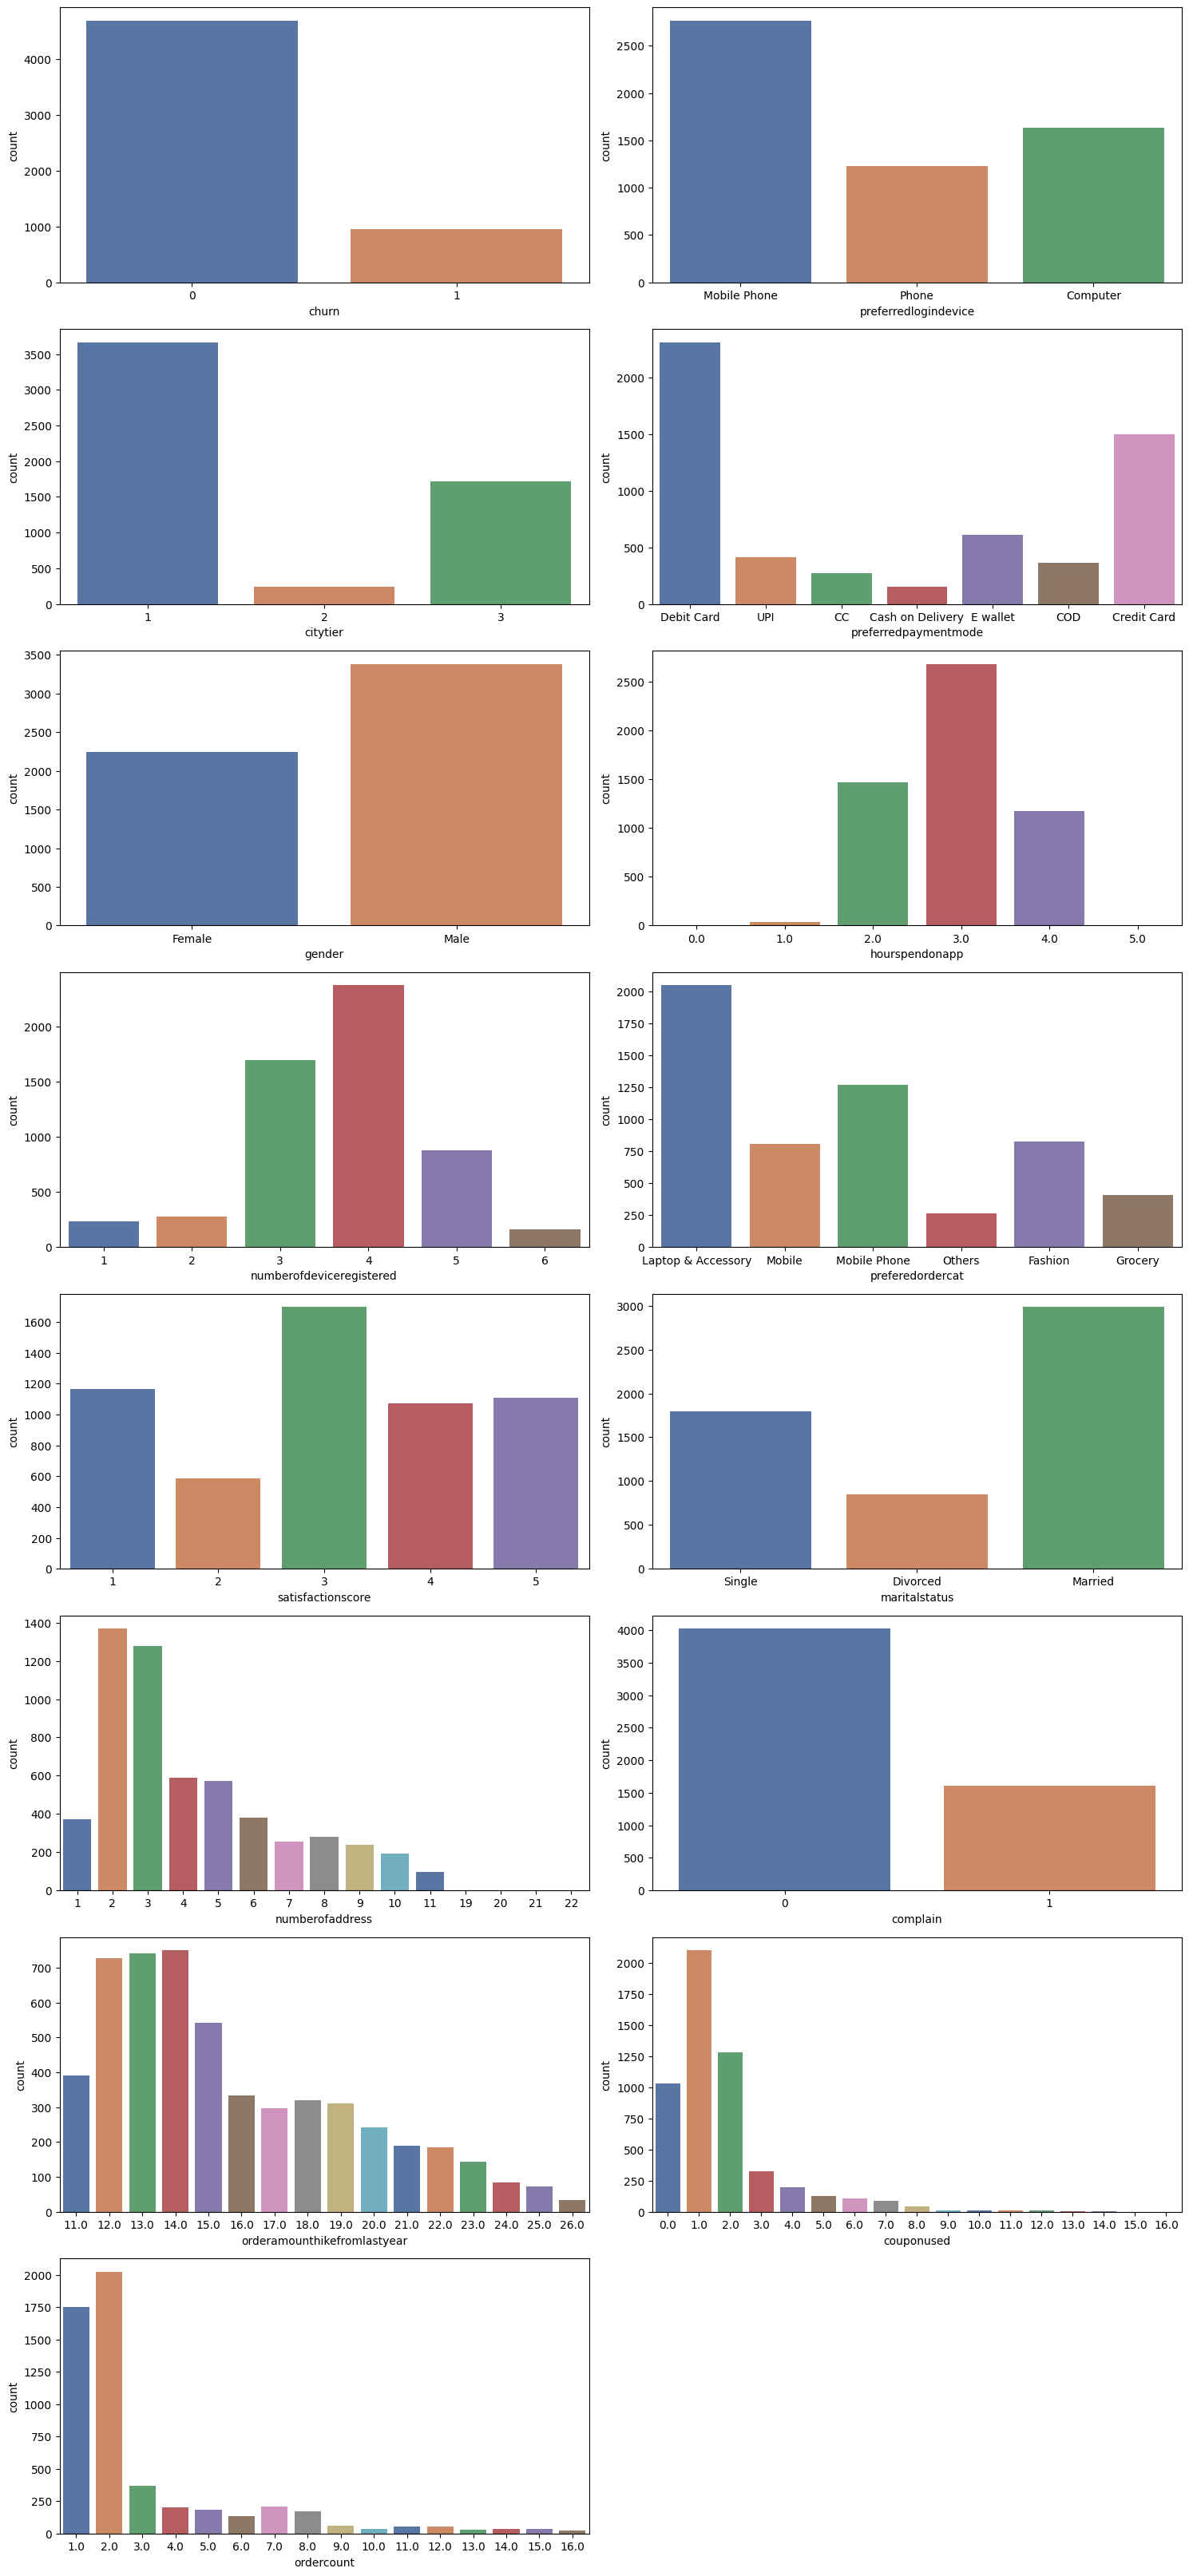

In [284]:
plt.figure(figsize=(15, 40))
plot_num = 1
for col in count_cols:
    plt.subplot(10,2, plot_num)
    sns.countplot(data=df, x=col, palette='deep')
    plot_num += 1
    plt.tight_layout()

#### Histogram for numerical columns

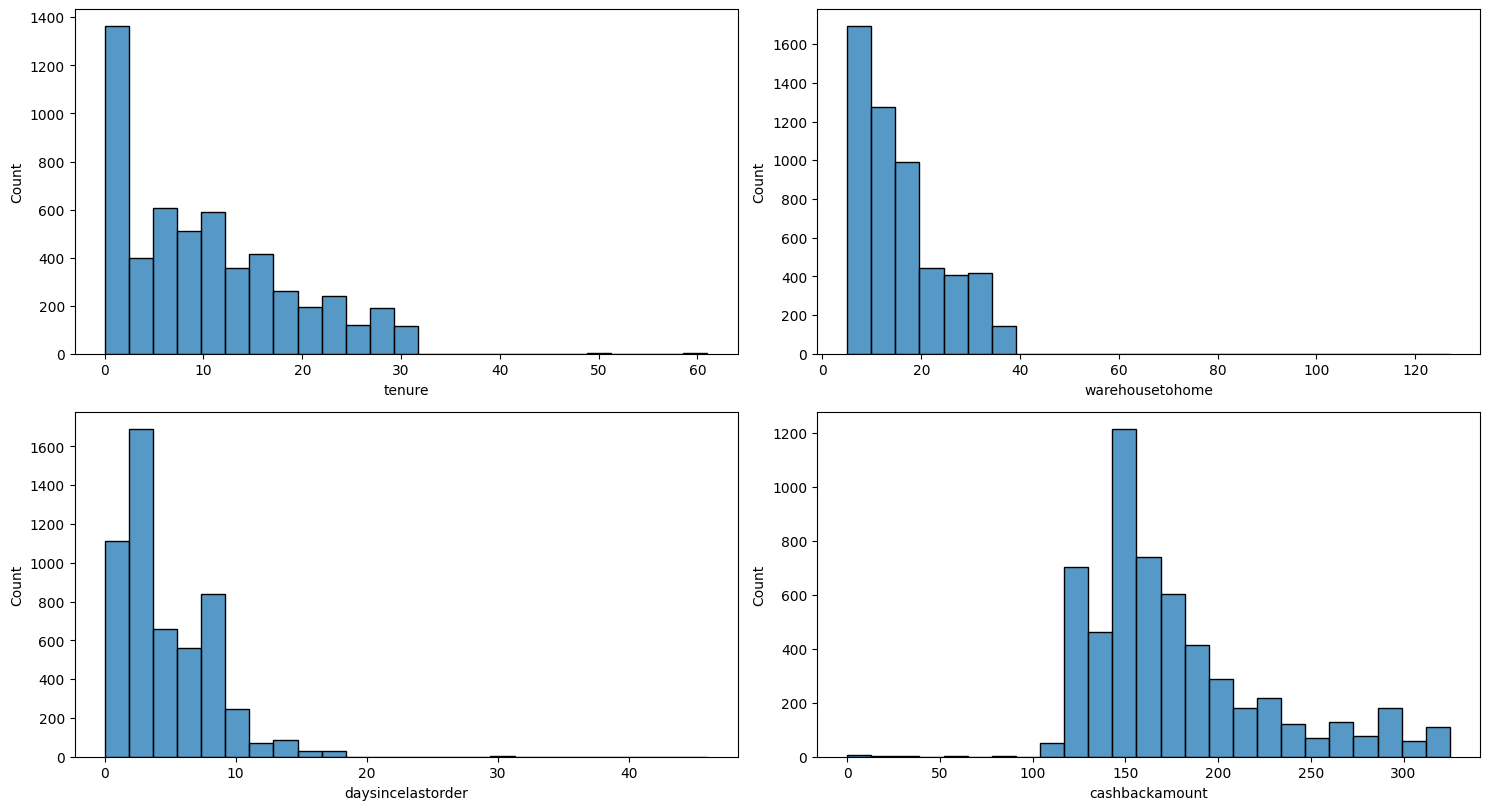

In [285]:
plt.figure(figsize=(15, 40))
plot_num = 1
for col in hist_cols:
    plt.subplot(10,2, plot_num)
    sns.histplot(data=df, x=col, bins=25)
    plot_num += 1
    plt.tight_layout()

#### Plot churn distribution for each categorical variable

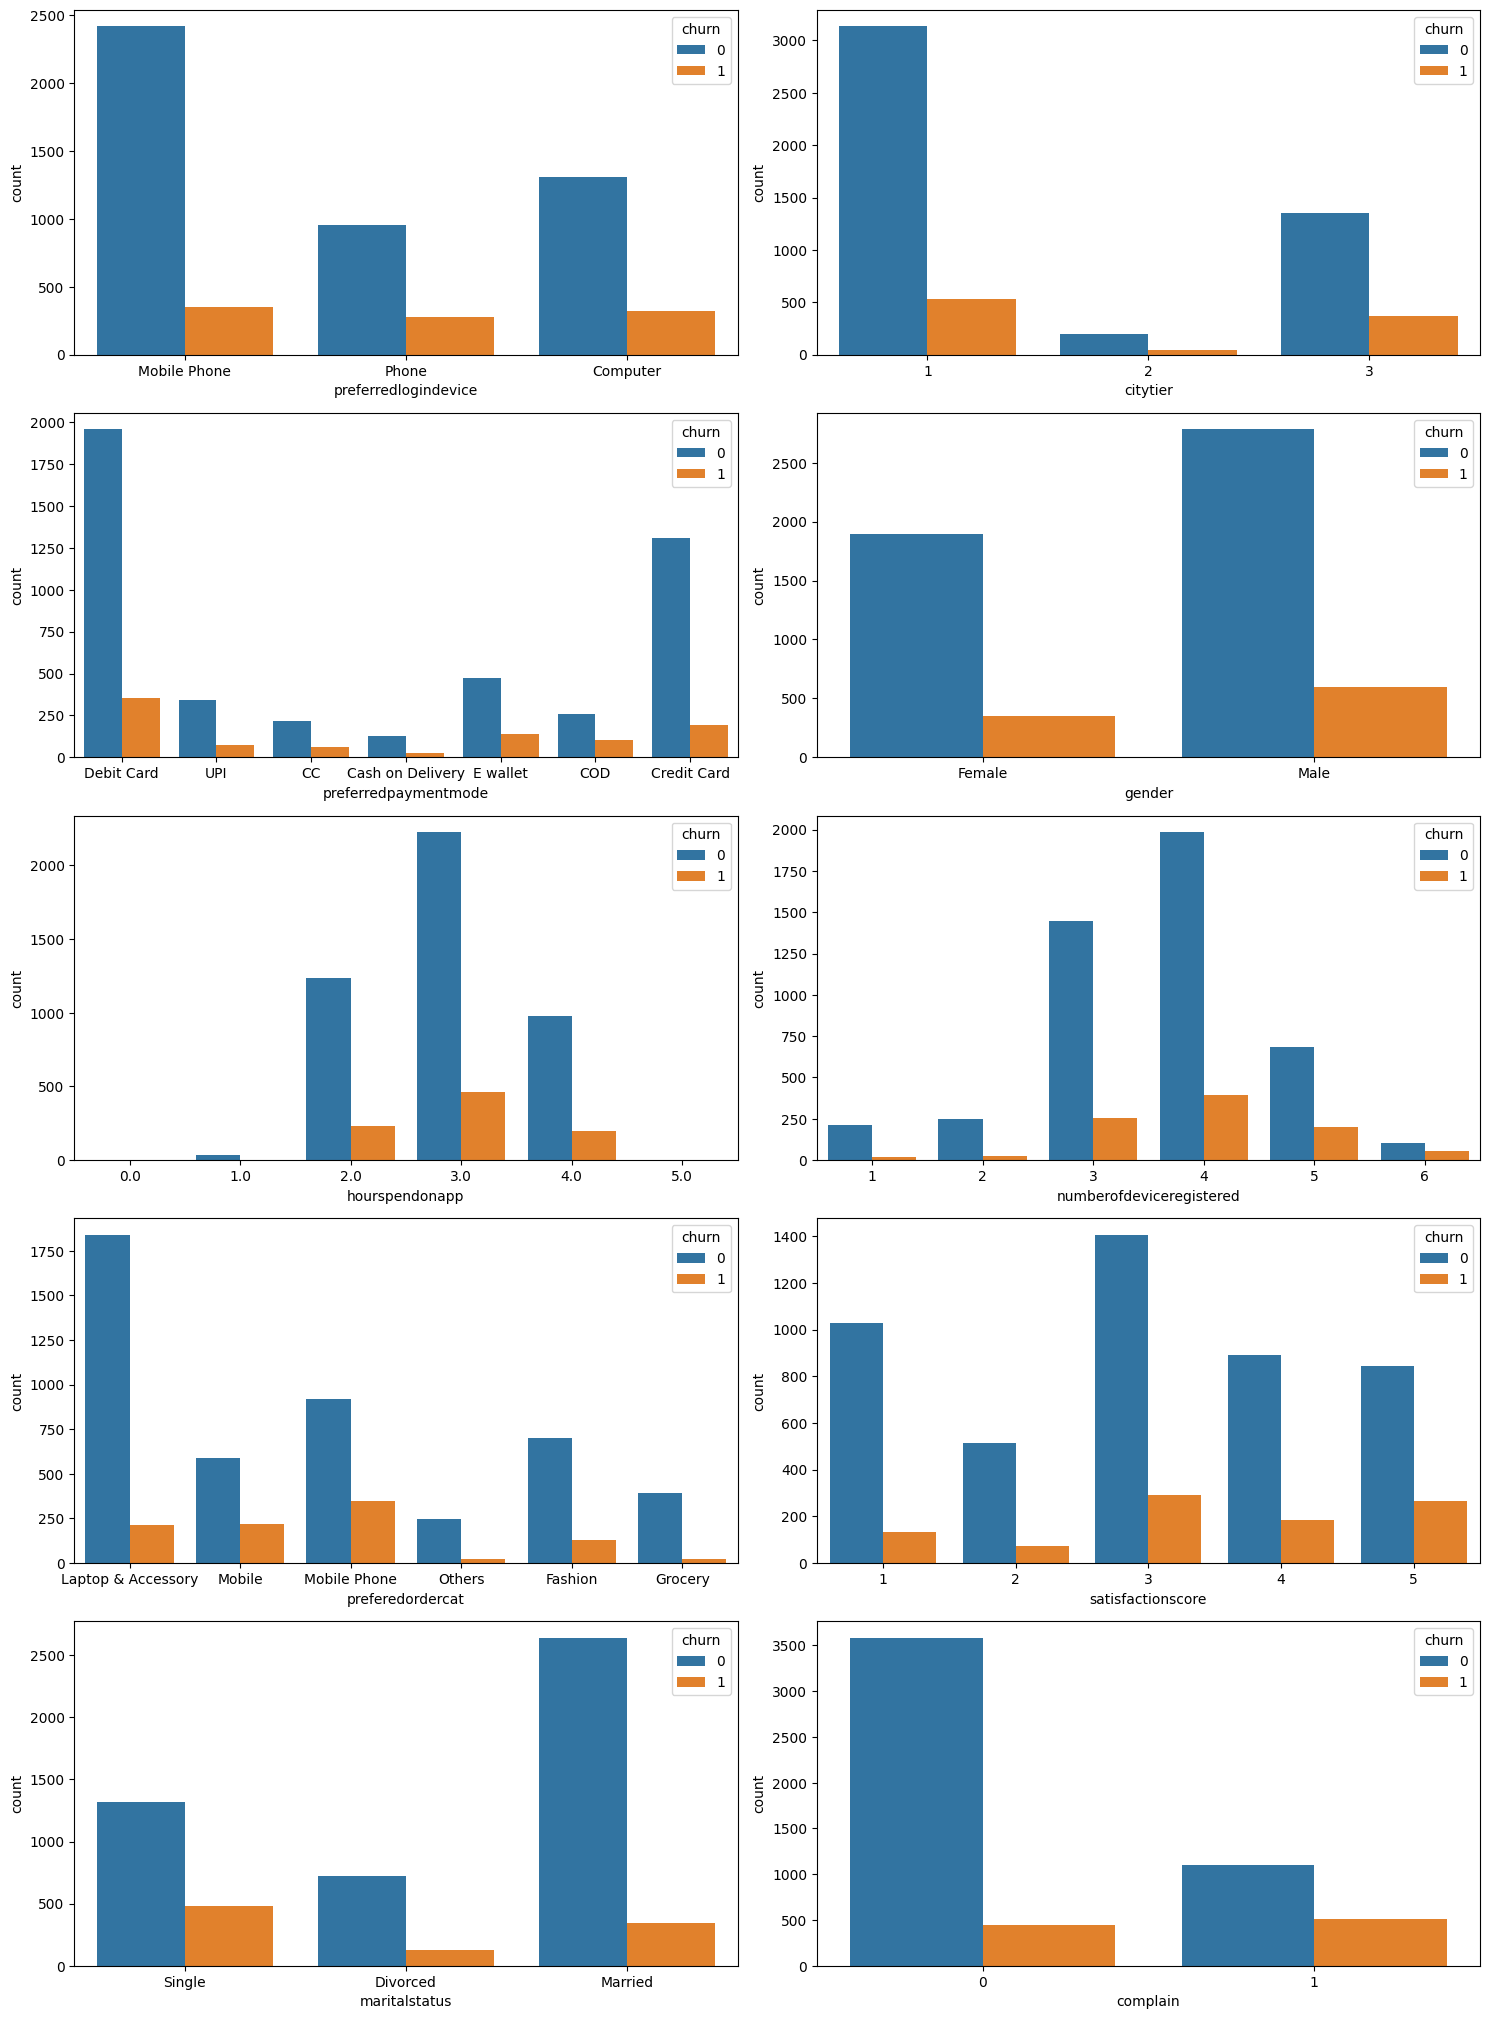

In [286]:
plt.figure(figsize=(15,40))
plot_num = 1
for col in count_cols:
    if df[col].nunique() <=8 and col != "churn":
        plt.subplot(10, 2, plot_num)
        sns.countplot(data=df, x=col, hue="churn")
        plot_num += 1
        plt.tight_layout()


### Impute Missing Values

In [287]:
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

def fill_missing_values(df, random_state = None):
    # identify numerical and categorical columns
    num_col = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    cat_col = df.select_dtypes(include=['object']).columns.tolist()

    # impute numeric columns
    num_imputer = SimpleImputer(strategy='mean')
    df[num_col] = num_imputer.fit_transform(df[num_col])

    # handle categorical columns
    for col in cat_col:
        if df[col].dtype == 'object':
            # convert columns using one hot encoding
            encoded_cols = pd.get_dummies(df[col], prefix=col)
            df = pd.concat([df.drop(col, axis=1), encoded_cols], axis=1)

    # random forest interative imputer for entire df
    rf_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=random_state))
    df = pd.DataFrame(rf_imputer.fit_transform(df), columns=df.columns)

    return df

#call the function
df = fill_missing_values(df, random_state=42)

In [288]:
df.head()

,churn,tenure,citytier,warehousetohome,hourspendonapp,numberofdeviceregistered,satisfactionscore,numberofaddress,complain,orderamounthikefromlastyear,couponused,ordercount,daysincelastorder,cashbackamount,preferredlogindevice_Computer,preferredlogindevice_Mobile Phone,preferredlogindevice_Phone,preferredpaymentmode_CC,preferredpaymentmode_COD,preferredpaymentmode_Cash on Delivery,preferredpaymentmode_Credit Card,preferredpaymentmode_Debit Card,preferredpaymentmode_E wallet,preferredpaymentmode_UPI,gender_Female,gender_Male,preferedordercat_Fashion,preferedordercat_Grocery,preferedordercat_Laptop & Accessory,preferedordercat_Mobile,preferedordercat_Mobile Phone,preferedordercat_Others,maritalstatus_Divorced,maritalstatus_Married,maritalstatus_Single
0,1.0,4.000000,3.0,6.0,3.000000,3.0,2.0,9.0,1.0,11.0,1.0,1.0,5.0,159.93,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,10.189899,1.0,8.0,3.000000,4.0,3.0,7.0,1.0,15.0,0.0,1.0,0.0,120.90,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1.0,10.189899,1.0,30.0,2.000000,4.0,3.0,6.0,1.0,14.0,0.0,1.0,3.0,120.28,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.000000,3.0,15.0,2.000000,4.0,5.0,8.0,0.0,23.0,0.0,1.0,3.0,134.07,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,0.000000,1.0,12.0,2.931535,3.0,5.0,3.0,0.0,11.0,1.0,1.0,3.0,129.60,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [289]:
df.isnull().sum()

churn                                    0
tenure                                   0
citytier                                 0
warehousetohome                          0
hourspendonapp                           0
numberofdeviceregistered                 0
satisfactionscore                        0
numberofaddress                          0
complain                                 0
orderamounthikefromlastyear              0
couponused                               0
ordercount                               0
daysincelastorder                        0
cashbackamount                           0
preferredlogindevice_Computer            0
preferredlogindevice_Mobile Phone        0
preferredlogindevice_Phone               0
preferredpaymentmode_CC                  0
preferredpaymentmode_COD                 0
preferredpaymentmode_Cash on Delivery    0
preferredpaymentmode_Credit Card         0
preferredpaymentmode_Debit Card          0
preferredpaymentmode_E wallet            0
preferredpa

### Model Building

In [290]:
# split dataset into training and test set
X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### handling the imbalanced dataset

In [291]:

from imblearn.over_sampling import SMOTE

print("Before unsampling count of label 0 {}".format(sum(y_train==0)))
print("Before unsampling count of label 1 {}".format(sum(y_train==1)))

# minority over sampling technique
sm = SMOTE(sampling_strategy = 1, random_state=42)
X_train_s, y_train_s = sm.fit_resample(X_train, y_train.ravel())

print("After unsampling count of label 0 {}".format(sum(y_train_s==0)))
print("After unsampling count of label 1 {}".format(sum(y_train_s==1)))

Before unsampling count of label 0 3741
Before unsampling count of label 1 763
After unsampling count of label 0 3741
After unsampling count of label 1 3741


#### Model Evaluation

In [292]:
# Libraries
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import feature_selection
from sklearn import model_selection
from sklearn import metrics

from sklearn.linear_model import LogisticRegressionCV, RidgeClassifierCV, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier, RandomForestClassifier 
from xgboost import XGBClassifier

In [293]:
# model initialization

models = [
    #Enemble
    AdaBoostClassifier(),
    BaggingClassifier(),
    GradientBoostingClassifier(),
    RandomForestClassifier(),

    #Linear Models
    LogisticRegressionCV(),
    RidgeClassifierCV(),

    KNeighborsClassifier(),

    XGBClassifier(),

]

metrics_cols = ['model_name', 'test_accuracy', 'test_percision', 'test_recall', 'test_f1']

model_name = []
test_accuracy =[]
test_precision = []
test_recall = []
test_f1 =[]

In [294]:
# model evaluation

scoring = ['accuracy', 'precision', 'recall', 'f1']

for model in models:
    cv_results = model_selection.cross_validate(model, X, y, cv=5, scoring=scoring, return_train_score=True)
    model_name.append(model.__class__.__name__)
    test_accuracy.append(round(cv_results['test_accuracy'].mean(), 3) * 100)
    test_precision.append(round(cv_results['test_precision'].mean(), 3) * 100)
    test_recall.append(round(cv_results['test_recall'].mean(), 3) * 100)
    test_f1.append(round(cv_results['test_f1'].mean(), 3) * 100)

metrics_data = [model_name, test_accuracy, test_precision, test_recall, test_f1]
m = {n:m for n,m in zip(metrics_cols, metrics_data)}
model_metrics = pd.DataFrame(m)
model_metrics = model_metrics.sort_values('test_accuracy', ascending=False)
metrics_styled = model_metrics.style.background_gradient(subset=['test_accuracy', 'test_f1'], cmap='summer')
metrics_styled


,model_name,test_accuracy,test_percision,test_recall,test_f1
7,XGBClassifier,99.200000,98.300000,96.900000,97.600000
3,RandomForestClassifier,98.500000,98.800000,92.100000,95.300000
1,BaggingClassifier,98.000000,97.200000,90.600000,93.800000
2,GradientBoostingClassifier,91.900000,85.200000,62.800000,72.200000
4,LogisticRegressionCV,89.300000,77.200000,51.800000,61.900000
0,AdaBoostClassifier,89.000000,72.900000,55.000000,62.500000
6,KNeighborsClassifier,87.500000,70.400000,44.800000,54.800000
5,RidgeClassifierCV,87.400000,86.500000,29.700000,44.300000


In [295]:
final_model = RandomForestClassifier()
final_model.fit(X_train, y_train)
train_pred = final_model.predict(X_train)
final_model.score(X_test, y_test)

0.9706927175843695

In [296]:
final_model = XGBClassifier()
final_model.fit(X_train, y_train)
train_pred = final_model.predict(X_train)

print(final_model.score(X_test, y_test))

pred = final_model.predict(X_test)
print("-" * 60)
print('Model Report without smote data')
print("-" * 60)
print(classification_report(y_test, pred))

0.9840142095914742
------------------------------------------------------------
Model Report without smote data
------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99       941
         1.0       0.99      0.91      0.95       185

    accuracy                           0.98      1126
   macro avg       0.99      0.96      0.97      1126
weighted avg       0.98      0.98      0.98      1126



In [297]:
# model for smote data

final_model_smote = XGBClassifier()
final_model_smote.fit(X_train_s, y_train_s)
train_pred = final_model_smote.predict(X_train_s)

print(final_model_smote.score(X_test, y_test))

pred = final_model_smote.predict(X_test)
print("-" * 60)
print('Model Report with smote data')
print("-" * 60)
print(classification_report(y_test, pred))

0.9795737122557726
------------------------------------------------------------
Model Report with smote data
------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99       941
         1.0       0.97      0.90      0.94       185

    accuracy                           0.98      1126
   macro avg       0.98      0.95      0.96      1126
weighted avg       0.98      0.98      0.98      1126



##### SMOTE was evaluated but did not improve performance, so the final model was trained on the original class distribution

### Feature Importance of XGBoost Model

- Importance_type<br>
    - 'weight' - The number of times a feature is used to split teh data across all trees.
    - 'gain' - The avg gain across all splits the feature is used in.

Feature Importance Gain


<Axes: >

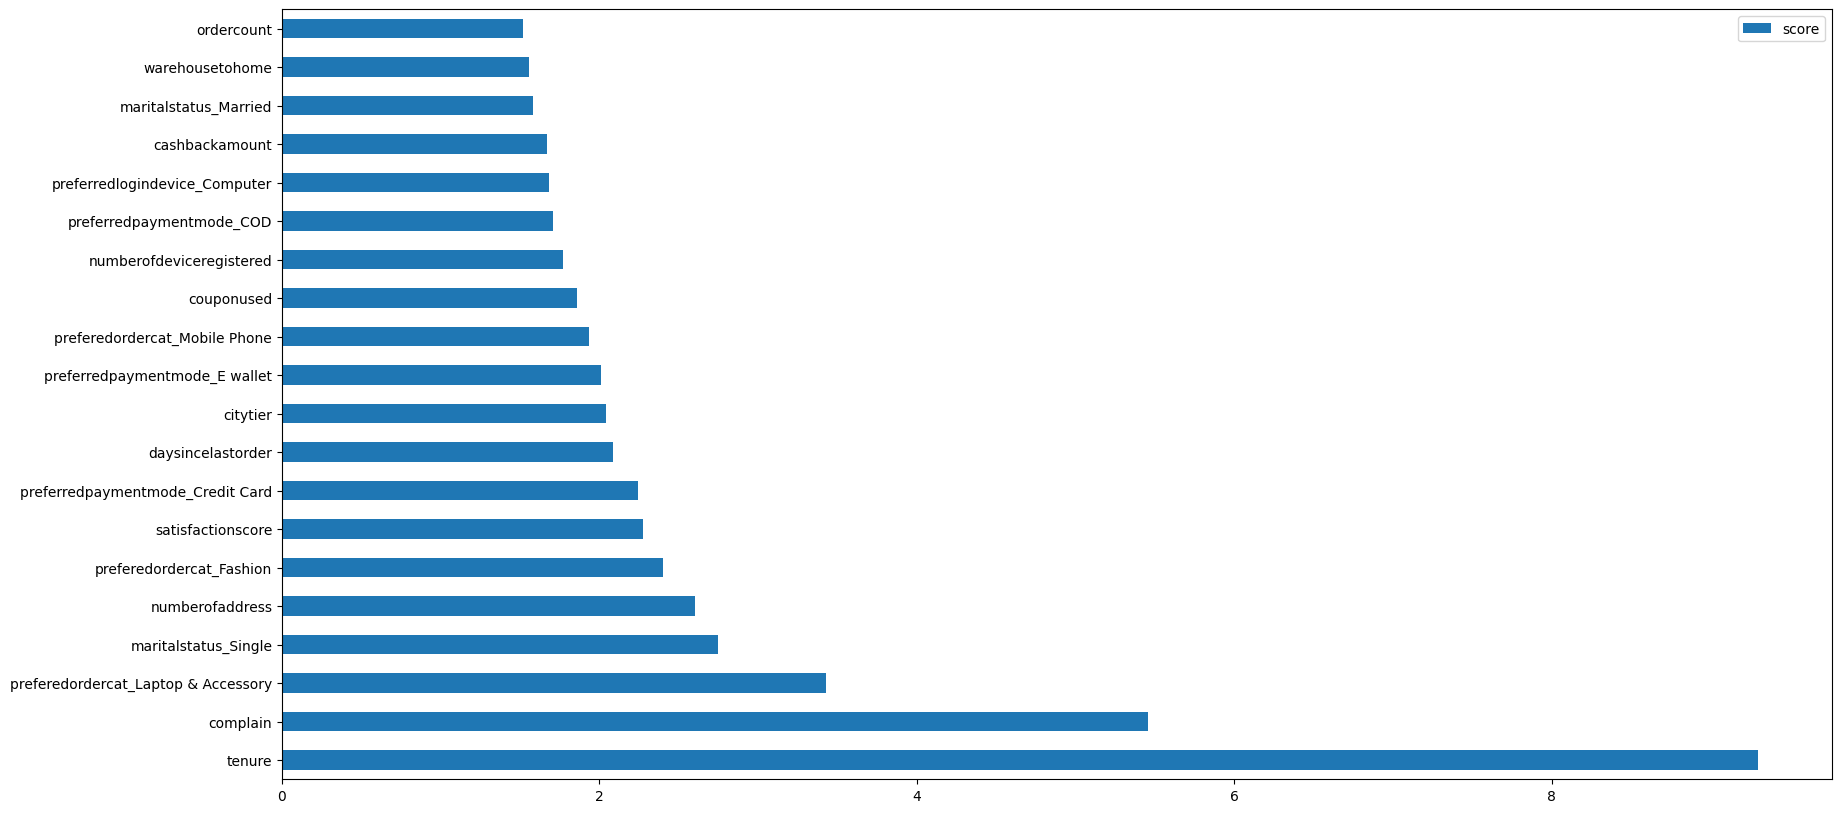

In [298]:
print("Feature Importance Gain")
feature_importance = final_model.get_booster().get_score(importance_type="gain")
keys = list(feature_importance.keys())
values = list(feature_importance.values())

data = pd.DataFrame(data=values, index=keys, columns=['score']).sort_values(by = "score", ascending=False)
data.nlargest(20, columns="score").plot(kind = 'barh', figsize=(20,10))

Feature Importance Weight


<Axes: >

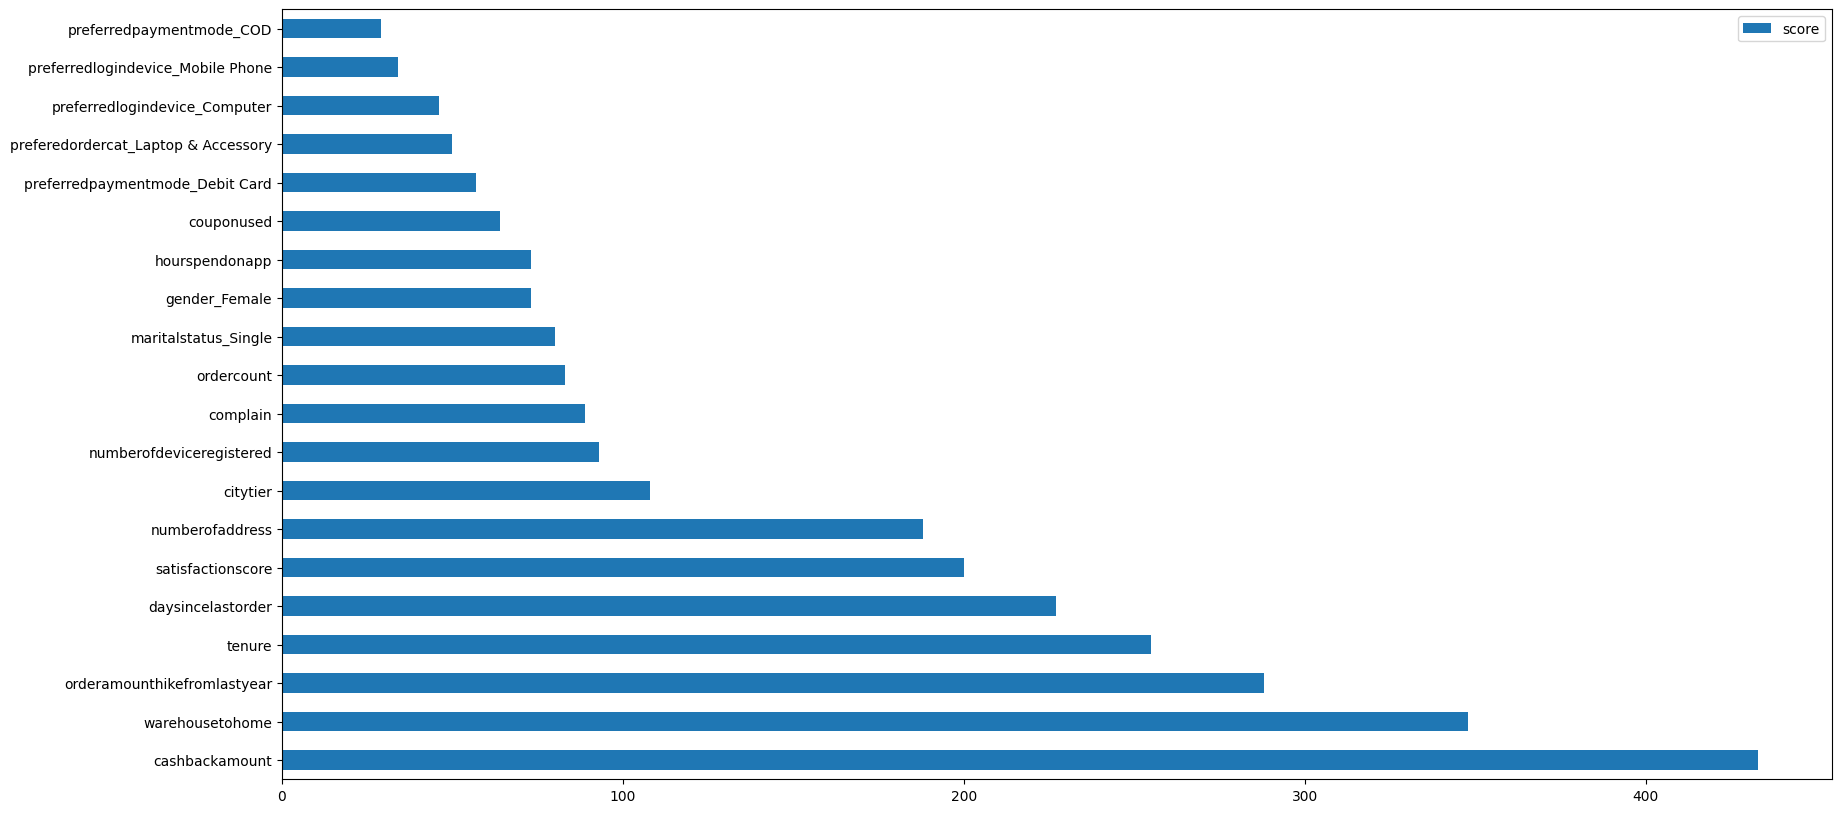

In [299]:
print("Feature Importance Weight")
feature_importance = final_model.get_booster().get_score(importance_type="weight")
keys = list(feature_importance.keys())
values = list(feature_importance.values())

data = pd.DataFrame(data=values, index=keys, columns=['score']).sort_values(by = "score", ascending=False)
data.nlargest(20, columns="score").plot(kind = 'barh', figsize=(20,10))

### Create Simpler models with less but more important features

- The features that will be used for final deployment model are:
    - Tenure
    - Cashback amount
    - City tier
    - Warehouse to home
    - Order amount hike from last year
    - Days ince lastorder
    - Satisfaction score
    - Number of address
    - Number ofdevice registered
    - Complain
    - Order count
    - hourspendonapp
    - Marital status
    - Coupon used
    - Gender

In [300]:
#select the columns
cols_to_drop = ['preferredlogindevice_Computer', 'preferredlogindevice_Mobile Phone', 'preferredlogindevice_Phone', 
                'preferredpaymentmode_CC', 'preferredpaymentmode_COD', 'preferredpaymentmode_Cash on Delivery', 'preferredpaymentmode_Credit Card', 
                'preferredpaymentmode_Debit Card', 'preferredpaymentmode_E wallet', 'preferredpaymentmode_UPI', 'preferedordercat_Fashion', 
                'preferedordercat_Grocery', 'preferedordercat_Laptop & Accessory', 'preferedordercat_Mobile', 'preferedordercat_Mobile Phone', 'preferedordercat_Others' ]
X.drop(cols_to_drop, axis = 1, inplace = True)

In [301]:
X_train.drop(cols_to_drop, axis = 1, inplace = True, errors='ignore')
X_test.drop(cols_to_drop, axis = 1, inplace = True, errors = 'ignore')

In [302]:
X.head()

,tenure,citytier,warehousetohome,hourspendonapp,numberofdeviceregistered,satisfactionscore,numberofaddress,complain,orderamounthikefromlastyear,couponused,ordercount,daysincelastorder,cashbackamount,gender_Female,gender_Male,maritalstatus_Divorced,maritalstatus_Married,maritalstatus_Single
0,4.000000,3.0,6.0,3.000000,3.0,2.0,9.0,1.0,11.0,1.0,1.0,5.0,159.93,1.0,0.0,0.0,0.0,1.0
1,10.189899,1.0,8.0,3.000000,4.0,3.0,7.0,1.0,15.0,0.0,1.0,0.0,120.90,0.0,1.0,0.0,0.0,1.0
2,10.189899,1.0,30.0,2.000000,4.0,3.0,6.0,1.0,14.0,0.0,1.0,3.0,120.28,0.0,1.0,0.0,0.0,1.0
3,0.000000,3.0,15.0,2.000000,4.0,5.0,8.0,0.0,23.0,0.0,1.0,3.0,134.07,0.0,1.0,0.0,0.0,1.0
4,0.000000,1.0,12.0,2.931535,3.0,5.0,3.0,0.0,11.0,1.0,1.0,3.0,129.60,0.0,1.0,0.0,0.0,1.0


### Evaluate the best model

In [303]:
# convert pandas df to numpy arrray for xgboost classifier

X_test = X_test.values
X_train = X_train.values

In [304]:
final_model = XGBClassifier()
final_model.fit(X_train, y_train)
train_pred = final_model.predict(X_train)
test_pred = final_model.predict(X_test)

final_model.score(X_test, y_test)

0.9813499111900533

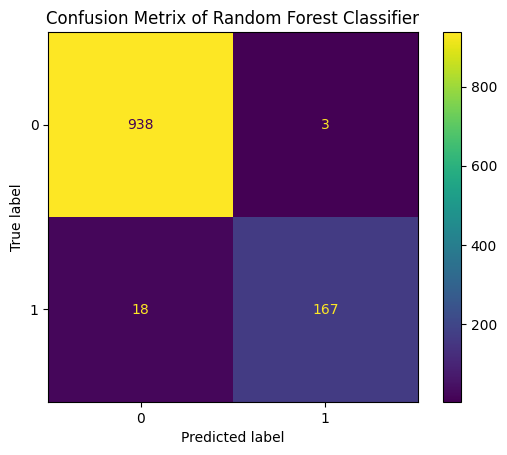

In [305]:
cm = confusion_matrix(y_test, test_pred, labels=final_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)
disp.plot()
plt.title('Confusion Metrix of Random Forest Classifier')
plt.show()

#### Model Predication

In [306]:
# make prediction on test set
y_pred = final_model.predict(X_test)

# Create a list to store actural and predicted values
results = []

#store low_price values in list
for actual, predicted in zip(y_test, y_pred):
    results.append((actual,predicted))

# convert list into dataframe
XGBoost_df = pd.DataFrame(results, columns=['Actual','Predicted'])

XGBoost_df.head(10)

,Actual,Predicted
0,1.0,1
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0
5,0.0,0
6,0.0,0
7,0.0,0
8,0.0,0
9,0.0,0


In [307]:
wrong_prediction = XGBoost_df[XGBoost_df['Actual'] != XGBoost_df['Predicted']]
wrong_prediction


,Actual,Predicted
193,0.0,1
194,1.0,0
196,1.0,0
206,0.0,1
217,1.0,0
283,1.0,0
359,1.0,0
373,1.0,0
427,1.0,0
513,1.0,0


### Save the Model

In [308]:
import joblib
joblib.dump(final_model,open('models\churn_prediction_model.pkl', 'wb'))

In [ ]:
import json

columns = {'data_columns': [col.lower() for col in X.columns]}

with open("columns.json", "w") as f:
    f.write(json.dumps(columns))

In [311]:
type(joblib.load("models\churn_prediction_model.pkl"))

xgboost.sklearn.XGBClassifier